# Session 1: 환경 세팅 & 데이터 탐색

## MLOps란?

**MLOps (Machine Learning Operations)** 는 머신러닝 모델을 개발부터 배포, 모니터링까지 체계적으로 관리하는 방법론입니다.

### 이 과정에서 만들 것

우리는 **대출 심사 자동화 시스템**을 처음부터 끝까지 구축합니다:

1. **데이터 탐색** (Session 1) - 데이터를 이해하고 인사이트 도출
2. **모델 학습** (Session 2) - XGBoost 모델 학습 및 Pipeline 구축
3. **API 기초** (Session 3) - FastAPI로 REST API 기본 구조 학습
4. **예측 API 구현** (Session 4) - 학습된 모델을 API로 서빙
5. **컨테이너화** (Session 5) - Docker로 패키징
6. **배포 & 모니터링** (Session 6) - 클라우드 배포 및 운영

### 왜 MLOps가 중요한가?

- 노트북에서 잘 동작하는 모델이 실제 서비스에서는 동작하지 않는 경우가 많습니다.
- 모델 재학습, 버전 관리, 성능 모니터링 등 운영 이슈를 체계적으로 다뤄야 합니다.
- 이 과정을 통해 **모델 개발 → 서빙 → 운영**의 전체 흐름을 경험합니다.

In [ ]:
!pip install fastapi uvicorn scikit-learn xgboost pandas joblib matplotlib seaborn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print('환경 설정 완료!')

환경 설정 완료!


## 대출 심사 데이터 소개

### 비즈니스 시나리오

우리는 은행의 **대출 심사 자동화 시스템**을 구축하는 ML 엔지니어입니다.

현재 대출 심사는 심사역이 수동으로 처리하고 있어 시간이 오래 걸리고, 일관성이 부족합니다.  
ML 모델을 활용하여 대출 승인 여부를 예측하는 API를 만들어 심사 프로세스를 자동화하려 합니다.

### 데이터 컬럼 설명

| 컬럼 | 설명 | 타입 |
|------|------|------|
| 나이 | 신청자 나이 | 수치형 |
| 성별 | 남/여 | 범주형 |
| 연소득 | 연간 소득 (만원) | 수치형 |
| 근속연수 | 현 직장 근속 기간 (년) | 수치형 |
| 주거형태 | 자가/전세/월세 | 범주형 |
| 신용점수 | 신용 평가 점수 | 수치형 |
| 기존대출건수 | 기존 대출 수 | 수치형 |
| 연간카드사용액 | 연간 카드 사용 금액 (만원) | 수치형 |
| 부채비율 | 소득 대비 부채 비율 (%) | 수치형 |
| 대출신청액 | 신청한 대출 금액 (만원) | 수치형 |
| 대출목적 | 대출 사유 | 범주형 |
| 상환방식 | 원금균등/원리금균등 등 | 범주형 |
| 대출기간 | 대출 기간 (개월) | 수치형 |
| 승인여부 | 대출 승인=1, 거절=0 (타겟) | 이진 |

In [7]:
!pip install joblib xgboost

  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
Using cached xgboost-3.2.0-py3-none-win_amd64.whl (101.7 MB)


In [3]:
# 1. 데이터 로드
df = pd.read_csv('../data/loan_data.csv')
print(f"데이터 shape: {df.shape}")
df.head()

데이터 shape: (1500, 14)


,나이,성별,연소득,근속연수,주거형태,신용점수,기존대출건수,연간카드사용액,부채비율,대출신청액,대출목적,상환방식,대출기간,승인여부
0,42,여,4500,16,전세,613,2,3140,28.5,3000,자동차,원금균등,36,1
1,36,남,2400,4,월세,437,3,1260,54.2,2200,주택구입,원리금균등,36,0
2,43,남,4900,15,월세,623,2,3210,28.2,3800,자동차,원리금균등,48,1
3,51,여,2500,22,자가,608,1,1720,35.7,5600,전세자금,원리금균등,36,0
4,35,여,3900,3,월세,549,0,1630,49.5,7300,생활비,원리금균등,24,0


In [4]:
# 2. 기본 탐색
print("=== 데이터 타입 ===")
print(df.dtypes)
print(f"\n=== 결측치 ===\n{df.isnull().sum()}")
print(f"\n=== 타겟 분포 ===\n{df['승인여부'].value_counts()}")
df.describe()

=== 데이터 타입 ===
나이           int64
성별          object
연소득          int64
근속연수         int64
주거형태        object
신용점수         int64
기존대출건수       int64
연간카드사용액      int64
부채비율       float64
대출신청액        int64
대출목적        object
상환방식        object
대출기간         int64
승인여부         int64
dtype: object

=== 결측치 ===
나이         0
성별         0
연소득        0
근속연수       0
주거형태       0
신용점수       0
기존대출건수     0
연간카드사용액    0
부채비율       0
대출신청액      0
대출목적       0
상환방식       0
대출기간       0
승인여부       0
dtype: int64

=== 타겟 분포 ===
승인여부
1    913
0    587
Name: count, dtype: int64


,나이,연소득,근속연수,신용점수,기존대출건수,연간카드사용액,부채비율,대출신청액,대출기간,승인여부
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,38.078667,3884.866667,6.074667,568.626667,1.258000,1757.760000,37.353867,3418.533333,36.840000,0.608667
std,8.582633,1521.267175,5.136927,86.603931,1.136206,995.241538,15.070179,1825.101964,13.990886,0.488211
min,23.000000,1500.000000,0.000000,300.000000,0.000000,280.000000,3.000000,500.000000,12.000000,0.000000
25%,32.000000,2800.000000,2.000000,510.750000,0.000000,1000.000000,25.975000,2200.000000,24.000000,0.000000
50%,38.000000,3650.000000,5.000000,569.000000,1.000000,1590.000000,36.500000,3000.000000,36.000000,1.000000
75%,44.000000,4700.000000,9.000000,626.000000,2.000000,2260.000000,47.825000,4200.000000,48.000000,1.000000
max,65.000000,13900.000000,30.000000,900.000000,5.000000,6620.000000,83.900000,15000.000000,60.000000,1.000000


In [5]:
# 3. 피처/타겟 분리 및 컬럼 정의
from sklearn.model_selection import train_test_split

X = df.drop('승인여부', axis=1)
y = df['승인여부']

# 수치형 / 범주형 컬럼 분리
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

print(f"수치형 컬럼 ({len(numerical_cols)}): {numerical_cols}")
print(f"범주형 컬럼 ({len(categorical_cols)}): {categorical_cols}")

# Train/Test 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain: {X_train.shape}, Test: {X_test.shape}")

수치형 컬럼 (9): ['나이', '연소득', '근속연수', '신용점수', '기존대출건수', '연간카드사용액', '부채비율', '대출신청액', '대출기간']
범주형 컬럼 (4): ['성별', '주거형태', '대출목적', '상환방식']

Train: (1200, 13), Test: (300, 13)


In [ ]:
# 4. Pipeline 구축 (전처리 + XGBoost)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from xgboost import XGBClassifier

# 수치형: StandardScaler / 범주형: OneHotEncoder
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ]
)

# 전처리 + 모델을 하나의 Pipeline으로 결합
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.1,
        random_state=42,
        eval_metric='logloss',
        use_label_encoder=False
    ))
])

print("Pipeline 구성:")
print(pipeline)

=== Classification Report ===
              precision    recall  f1-score   support

       거절(0)       0.80      0.84      0.82       117
       승인(1)       0.89      0.86      0.88       183

    accuracy                           0.85       300
   macro avg       0.84      0.85      0.85       300
weighted avg       0.86      0.85      0.85       300

ROC-AUC Score: 0.9253


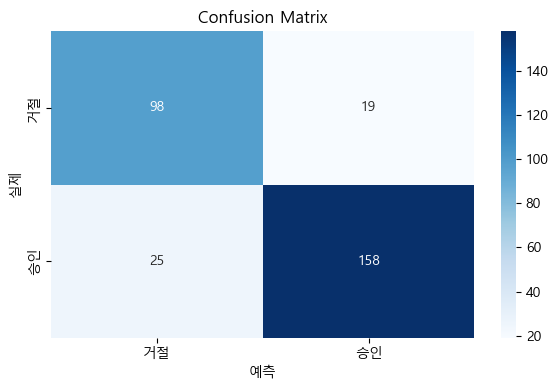

In [9]:
# 5. 모델 학습 및 평가
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# 학습
pipeline.fit(X_train, y_train)

# 예측
y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]

# 평가
print("=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=['거절(0)', '승인(1)']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")

# Confusion Matrix 시각화
fig, ax = plt.subplots(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['거절', '승인'], yticklabels=['거절', '승인'], ax=ax)
ax.set_xlabel('예측')
ax.set_ylabel('실제')
ax.set_title('Confusion Matrix')
plt.tight_layout()
plt.show()

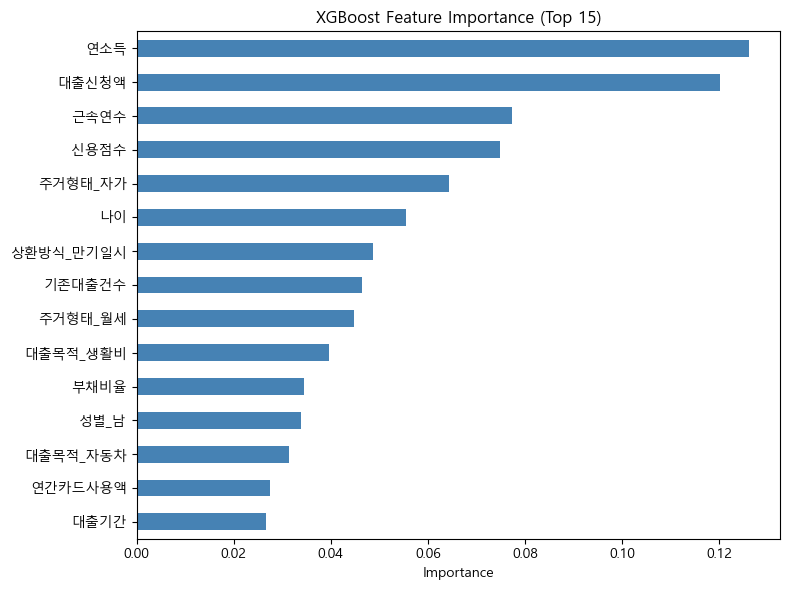

In [10]:
# 6. Feature Importance 시각화
feature_names = (numerical_cols + 
                 pipeline.named_steps['preprocessor']
                 .named_transformers_['cat']
                 .get_feature_names_out(categorical_cols).tolist())

importances = pipeline.named_steps['classifier'].feature_importances_

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
feat_imp.tail(15).plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('XGBoost Feature Importance (Top 15)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

In [11]:
# 7. Pipeline 저장 (다음 세션에서 API 서빙에 활용)
import joblib

joblib.dump(pipeline, '../models/loan_pipeline.pkl')
print("Pipeline 저장 완료: ../models/loan_pipeline.pkl")

# 저장된 파이프라인 로드 테스트
loaded_pipeline = joblib.load('../models/loan_pipeline.pkl')
test_pred = loaded_pipeline.predict(X_test[:3])
print(f"로드 테스트 예측 결과: {test_pred}")

Pipeline 저장 완료: ../models/loan_pipeline.pkl
로드 테스트 예측 결과: [1 1 0]


## 데이터 탐색 인사이트 정리

### 발견한 주요 사항

1. **타겟 분포**: 승인여부의 분포를 확인하여 클래스 불균형 여부를 파악했습니다.
2. **신용점수**: 승인 그룹이 거절 그룹보다 신용점수가 높은 경향이 뚜렷합니다. → 중요한 피처
3. **연소득**: 승인 그룹의 연소득이 상대적으로 높습니다.
4. **부채비율**: 부채비율이 높을수록 거절될 가능성이 높습니다.
5. **범주형 변수**: 주거형태, 대출목적 등에 따라 승인율 차이가 존재합니다.



In [12]:
import os

os.makedirs('../models', exist_ok=True)

In [14]:
joblib.dump(pipeline, '../models/loan_pipeline.pkl')

['../models/loan_pipeline.pkl']

In [ ]:
joblib.dump(pipeline, '../models/loan_pipeline.pkl')